In [1]:
import tokenizers
from pathlib import Path
from datasets import load_dataset, concatenate_datasets, interleave_datasets
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers
import json
import string

import torch
from torch import nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset, IterableDataset, get_worker_info

from src.minilm.model.model import Model
from src.minilm.training.schedule import get_lr_scheduler
from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter

import seaborn as sns
sns.set_theme()

In [2]:
VOCAB_SIZE = 16_000

In [3]:
def train_tokeniser():

    if Path("tokeniser.json").exists():
        return Tokenizer.from_file("tokeniser.json") 

    cosmopedia = load_dataset("parquet", data_files="data/smollm-corpus-dev/cosmopedia-v2/*.parquet", split="train", streaming=True)
    fineweb = load_dataset("parquet", data_files="data/smollm-corpus-dev/fineweb-edu-dedup/*.parquet", split="train", streaming=True)
    combined = interleave_datasets([cosmopedia, fineweb])

    def batch_iterator(dataset, text_column="text", batch_size=1000):
        batch = []

        for example in dataset:
            text = example.get(text_column)

            batch.append(text)

            if len(batch) == batch_size:
                yield batch
                batch = []

        if batch:
            yield batch


    tokenizer = Tokenizer(models.BPE())
    tokenizer.normalizer = normalizers.NFKC()
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tokenizer.decoder = tokenizers.decoders.ByteLevel()


    special_tokens = [
        "<|pad|>",
        "<|eos|>",

        "<|system|>",
        "<|user|>",
        "<|assistant|>",
        "<|tool|>",

        "<|end_message|>",

        "<|think|>",
        "<|end_think|>",

        "<|tool_call|>",
        "<|end_tool_call|>",

    ]

    special_tokens.extend([
        f"<|AA.{a}|>" for a in set(string.ascii_letters.upper()) 
    ])

    trainer = trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE,
        special_tokens=special_tokens,
    )

    tokenizer.train_from_iterator(batch_iterator(combined), trainer=trainer)

    tokenizer.save("tokeniser.json")
    return tokenizer

In [4]:
text = "The quick brown fox jumps over the lazy dog"

tokeniser = train_tokeniser()

encoding = tokeniser.encode(text)
ids = encoding.ids

print([tokeniser.decode([i]) for i in ids])


['The', ' quick', ' brown', ' f', 'ox', ' j', 'umps', ' over', ' the', ' l', 'az', 'y', ' dog']


In [5]:
cosmopedia = load_dataset("parquet", data_files="data/smollm-corpus-dev/cosmopedia-v2/*.parquet", split="train", streaming=True)

In [6]:
eos_token = tokeniser.token_to_id("<|eos|>")
eos_token

1

In [7]:
tokeniser.enable_truncation(max_length=1001)

In [8]:
class TextDataset(IterableDataset):
    def __iter__(self):
        dataset = load_dataset(
            "parquet",
            data_files="data/smollm-corpus-dev/cosmopedia-v2/*.parquet",
            split="train",
            streaming=True,
        )

        batch = []

        for example in dataset:
            batch.append(example["text"])

            if len(batch) == 256:
                yield from self._encode(batch)
                batch.clear()

        if batch:
            yield from self._encode(batch)

    @staticmethod
    def _encode(texts):
        for encoding in tokeniser.encode_batch(texts):
            input_ids = encoding.ids
            target_ids = input_ids[1:] + [eos_token]

            yield (
                torch.tensor(input_ids, dtype=torch.long),
                torch.tensor(target_ids, dtype=torch.long),
            )

In [9]:
def collate_fn(batch):
    xs, ys = zip(*batch)

    x = nn.utils.rnn.pad_sequence(
        xs,
        batch_first=True,
        padding_value=0,
    )

    # Padding targets with -100 lets CrossEntropyLoss ignore them.
    y = nn.utils.rnn.pad_sequence(
        ys,
        batch_first=True,
        padding_value=-100, # ignore index
    )

    # True means a real, non-padding input token.
    valid_tokens = x != 0

    return x, y, valid_tokens

In [10]:
device = "cuda"

In [11]:
model = Model(vocab_size=tokeniser.get_vocab_size(), d_model=64*4, n_layers=6, padding_idx=tokeniser.token_to_id("<|pad|>")).to(device)
print(f"num params: {sum(p.numel() for p in model.parameters()):,}")

# model = torch.compile(model, dynamic=True)

num params: 10,390,784


In [12]:
batch_size = 32
accum_steps = 16

dataset = TextDataset()
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=1)

effective_size = batch_size * accum_steps
print(effective_size)

512


In [13]:
opt = torch.optim.AdamW(model.parameters(), fused=True)

In [14]:
max_steps = 1000
steps = 0
losses = []
epochs = 0


scheduler = torch.optim.lr_scheduler.LambdaLR(
    opt,
    lr_lambda=get_lr_scheduler(start_factor=0.01, end_factor=0.1, warmup_steps=max_steps*0.01, constant_steps=max_steps*0.1, decay_steps=max_steps*0.9),
)

writer = SummaryWriter()

pbar = tqdm(total=max_steps)

while steps < max_steps:

    model.zero_grad()
    accum_loss = 0


    for i, (x, y, mask) in enumerate(dataloader):
        epochs += 1

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)


        with torch.autocast(device_type="cuda"):
            y_pred = model(x, mask)
            loss = F.cross_entropy(y_pred.transpose(1, 2), y) / accum_steps
            accum_loss += loss.item()

        loss.backward()

        if (i + 1) % accum_steps == 0:
            opt.step()
            opt.zero_grad()
            steps += 1
            pbar.update()
            losses.append(accum_loss)
            writer.add_scalar('Loss', accum_loss, steps)
            accum_loss = 0

            scheduler.step()
            writer.add_scalar('LR', opt.param_groups[0]['lr'], steps)


        if steps % 100 == 0:
            with torch.no_grad():

                prompts = ["Hello",
                            "Maya opened the small wooden box. Inside, she found",
                            "The glass fell from the table and hit the floor. It",
                            "Anna gave the book to Leo. Leo put it in his bag. Later, he",
                            "What is the capital of France?",
                            "The capital of France is",
                            "The dog heard a noise outside, so it",
                            "Two plus three equals",
                            "Sarah was hungry. She went to the kitchen and",
                            "The sun rises in the",
                            "This sentence is false. Therefore, it is",
                            "The door was locked from the inside, but when Nina opened it,"
                            "Every bird in the cage is blue. The red bird in the cage is"
                            "Once upon a"]

                for pi, prompt in enumerate(prompts, 1):
                    prompt_ids = tokeniser.encode(prompt).ids

                    for i in range(10):

                        logits = model(torch.LongTensor([prompt_ids]).to(device))[0, -1]
                        logits = F.softmax(logits, dim=0)
                        next_id = torch.multinomial(logits, num_samples=1).item()
                        prompt_ids.append(next_id)

                    writer.add_text(f'prompt{pi}', tokeniser.decode(prompt_ids), steps)

        if steps > max_steps:
            break


pbar.close()
writer.close()

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print(epochs)

In [ ]:
sns.lineplot(losses)

/tmp/ipykernel_24971/2271277982.py:50: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


<Axes: >

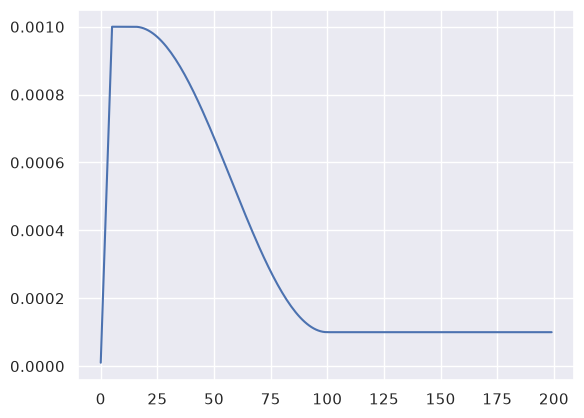

In [ ]:
import math

base_lr = 1e-3

warmup_steps = 5
constant_steps = 10
cosine_steps = 85

start_factor = 0.01
min_factor = 0.1

model = nn.Linear(10, 10)
opt = torch.optim.SGD(model.parameters(), lr=base_lr)


def lr_factor(step: int) -> float:
    # 1. Linear warmup
    if step < warmup_steps:
        progress = step / warmup_steps
        return start_factor + progress * (1.0 - start_factor)

    # 2. Constant base LR
    if step < warmup_steps + constant_steps:
        return 1.0

    # 3. Cosine decay
    schedule_end = warmup_steps + constant_steps + cosine_steps

    if step < schedule_end:
        cosine_step = step - warmup_steps - constant_steps
        progress = cosine_step / cosine_steps

        return min_factor + 0.5 * (1.0 - min_factor) * (
            1.0 + math.cos(math.pi * progress)
        )

    # 4. Hold forever at eta_min
    return min_factor


scheduler = torch.optim.lr_scheduler.LambdaLR(
    opt,
    lr_lambda=lr_factor,
)


lrs = []
for i in range(200):
    lrs.append(opt.param_groups[0]['lr'])
    scheduler.step()

sns.lineplot(lrs)


0.001